In [278]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report



In [279]:
zip_path = "/content/Plant_Disease_Workshop.zip"
extract_path = "/content"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")


Dataset extracted successfully!


In [280]:
print(os.listdir("/content"))

['.config', 'Plant_Disease_Workshop', 'pexels-mohamed-b-2151113020-36315671.jpg', 'Plant_Disease_Workshop.zip', 'vibrant-green-leaf-isolated-transparent-background_84443-64997.avif', 'tiger-jpg.jpg', 'sample_data']


In [281]:
dataset_path = "/content/Plant_Disease_Workshop"
print(os.listdir(dataset_path))

['val', 'train']


In [282]:
dataset_path = "/content/Plant_Disease_Workshop/train"
print(os.listdir(dataset_path))

['Potato___Late_blight', 'Potato___Early_blight', 'Potato___healthy']


In [283]:
dataset_path = "/content/Plant_Disease_Workshop/val"
print(os.listdir(dataset_path))

['Potato___Late_blight', 'Potato___Early_blight', 'Potato___healthy']


In [284]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"

print("===========TRAIN DATA ==========\n")
for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)
    print(folder, ":", len(os.listdir(folder_path)), "image")

print("\n===========VALIDATION DATA ==========\n")
for folder in os.listdir(val_path):
    folder_path = os.path.join(val_path, folder)
    print(folder, ":", len(os.listdir(folder_path)), "image")



===========TRAIN DATA ==========

Potato___Late_blight : 800 image
Potato___Early_blight : 800 image
Potato___healthy : 121 image

===========VALIDATION DATA ==========

Potato___Late_blight : 200 image
Potato___Early_blight : 200 image
Potato___healthy : 31 image


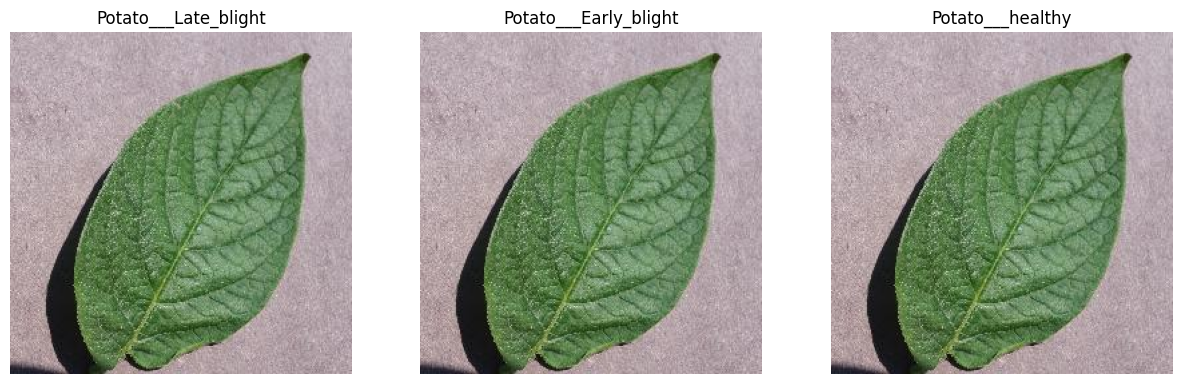

In [285]:
plt.figure(figsize=(15,5))
classes = os.listdir(train_path)
for i, folder in enumerate(classes):
    image_name = os.path.join(folder_path,os.listdir(folder_path)[0])
    image_path = os.path.join(train_path,folder,image_name)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    plt.subplot(1,3,i+1)
    plt.imshow(image)
    plt.title(folder)
    plt.axis("off")
plt.show()


In [286]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"
image_size =(64,64)


In [287]:
X_train = []
y_train = []

X_val = []
y_val = []

In [288]:
for label in os.listdir(train_path):
  folder_path = os.path.join(train_path, label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path, image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    X_train.append(image)
    y_train.append(label)
print("Training Image Loaded Successfully")

Training Image Loaded Successfully


In [289]:
for label in os.listdir(val_path):
  folder_path = os.path.join(val_path, label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path, image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    X_val.append(image)
    y_val.append(label)
print("Validation Image Loaded Successfully")





Validation Image Loaded Successfully


In [290]:
print("Training Images :",len(X_train))
print("Training Labels :",len(y_train))
print()
print("Validation Images:",len(X_val))
print("Validation Labels:",len(y_val))
print()

Training Images : 1721
Training Labels : 1721

Validation Images: 431
Validation Labels: 431



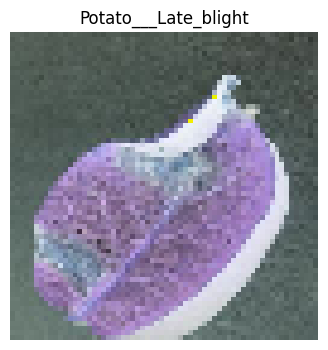

In [306]:
image_to_display = X_train[0].reshape(image_size[0], image_size[1], 3)
image_to_display = (image_to_display * 255).astype(np.uint8)

plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(image_to_display, cv2.COLOR_BGR2RGB))

if 'encoder' not in globals():
    from sklearn.preprocessing import LabelEncoder
    encoder = LabelEncoder()
    encoder.fit(y_train)

numerical_label = encoder.transform([y_train[0]])[0]
label_to_display = encoder.inverse_transform([numerical_label])[0]

plt.title(label_to_display)
plt.axis("off")
plt.show()

In [307]:
X_train = np.array(X_train)
X_val = np.array(X_val)
y_train = np.array(y_train)
y_val = np.array(y_val)
print("Converted Successfully!")

Converted Successfully!


In [308]:
print("Training shape :",X_train.shape)
print("Validation shape:",X_val.shape)


Training shape : (1721, 64, 64, 3)
Validation shape: (431, 12288)


In [309]:
X_train = X_train.reshape(X_train.shape[0],-1)
X_val = X_val.reshape(X_val.shape[0],-1)
print("Images Flattened Successfully!")

Images Flattened Successfully!


In [310]:
print("Training shape :",X_train.shape)
print("Validation shape:",X_val.shape)

Training shape : (1721, 12288)
Validation shape: (431, 12288)


In [311]:
X_train = X_train/255.0
X_val = X_val/255.0
print("Normalized Completed!")

Normalized Completed!


In [312]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)
print("Labels Encoded Successfully")

Labels Encoded Successfully


In [313]:
print("Encoded Classes:")
print(encoder.classes_)
print()
print("First 10 Labels:")
print(y_train[:10])

Encoded Classes:
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

First 10 Labels:
[1 1 1 1 1 1 1 1 1 1]


In [314]:
print("Training Features shape :",X_train.shape)
print("Training Labels shape :",y_train.shape)
print()
print("Validation Features shape:",X_val.shape)
print("Validation Labels shape:",y_val.shape)

Training Features shape : (1721, 12288)
Training Labels shape : (1721,)

Validation Features shape: (431, 12288)
Validation Labels shape: (431,)


In [315]:
logistic_model = LogisticRegression(max_iter=1000)
print("Logistic Regression Model Created Successfully!")

Logistic Regression Model Created Successfully!


In [316]:
logistic_model.fit(X_train,y_train)
print("Model training completed")

Model training completed


In [317]:
y_pred = logistic_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [318]:
print("Actual Labels  :", y_val[:10])
print("Predicted Labels:", y_pred[:10])

Actual Labels  : [1 1 1 1 1 1 1 1 1 1]
Predicted Labels: [1 1 1 1 1 1 1 1 1 1]


In [319]:
acc = accuracy_score(y_val, y_pred)
print("Accuracy Score is :",round(acc * 100,2),"%")



Accuracy Score is : 46.4 %


In [320]:
cmx = confusion_matrix(y_val, y_pred)
print(cmx)

[[  0 200   0]
 [  0 200   0]
 [  0  31   0]]


In [321]:
print(classification_report(y_val, y_pred, target_names=encoder.classes_))

                       precision    recall  f1-score   support

Potato___Early_blight       0.00      0.00      0.00       200
 Potato___Late_blight       0.46      1.00      0.63       200
     Potato___healthy       0.00      0.00      0.00        31

             accuracy                           0.46       431
            macro avg       0.15      0.33      0.21       431
         weighted avg       0.22      0.46      0.29       431



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [322]:
predicted_labels = encoder.inverse_transform(y_pred[:10])
print("First 10 Predicted Disease Names:")
print(predicted_labels)

First 10 Predicted Disease Names:
['Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight']


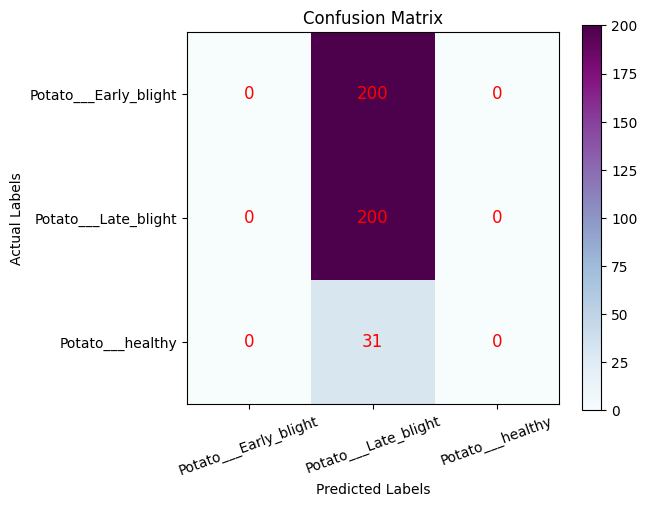

In [323]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(cmx,cmap="BuPu")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(3), encoder.classes_, rotation=20)
plt.yticks(range(3), encoder.classes_)
for i in range(len(cmx)):
  for j in range(len(cmx)):
    plt.text(j, i, cmx[i, j], ha='center', va='center', color='red',fontsize=12)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()

In [324]:
print("="*40)
print("Logistic Regression Completed Successfully")
print("="*40)
print(f"Accuracy : {acc*100:.2f}%")

Logistic Regression Completed Successfully
Accuracy : 46.40%


In [325]:
svm_model = SVC(kernel ="linear")
print("Support Vector Machine Model Created Successfully!")

Support Vector Machine Model Created Successfully!


In [326]:
svm_model.fit(X_train,y_train)
print("Model Trainning Completed")

Model Trainning Completed


In [327]:
y_pred=svm_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [328]:
acc = accuracy_score(y_val,svm_pred)
print("Accuracy:",round(svm_acc * 100,2),"%")

Accuracy: 91.18 %


In [329]:
svm = confusion_matrix(y_val, y_pred)
print("Confusion matrix :",cmx)

Confusion matrix : [[  0 200   0]
 [  0 200   0]
 [  0  31   0]]


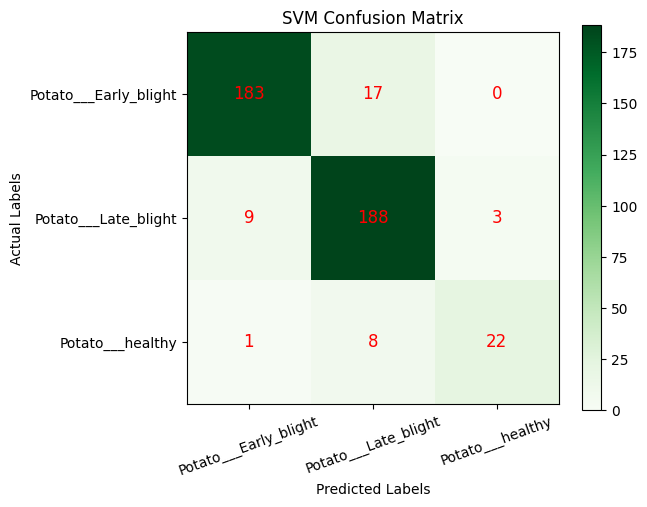

In [301]:
plt.figure(figsize=(6,5))
plt.imshow(cmx,cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.colorbar()
plt.xticks(range(3), encoder.classes_, rotation=20)
plt.yticks(range(3), encoder.classes_)
for i in range(len(cmx)):
  for j in range(len(cmx)):
    plt.text(j, i, cmx[i, j], ha='center', va='center', color='red',fontsize=12)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()

In [293]:
print("="*40)
print("SVM Completed Successfully!")
print("="*40)

print(f"Accuracy : {round(svm_acc*100,2)}%")

SVM Completed Successfully!
Accuracy : 91.18%


In [303]:
from google.colab import files

uploaded = files.upload()

Saving pexels-mohamed-b-2151113020-36315671.jpg to pexels-mohamed-b-2151113020-36315671 (1).jpg


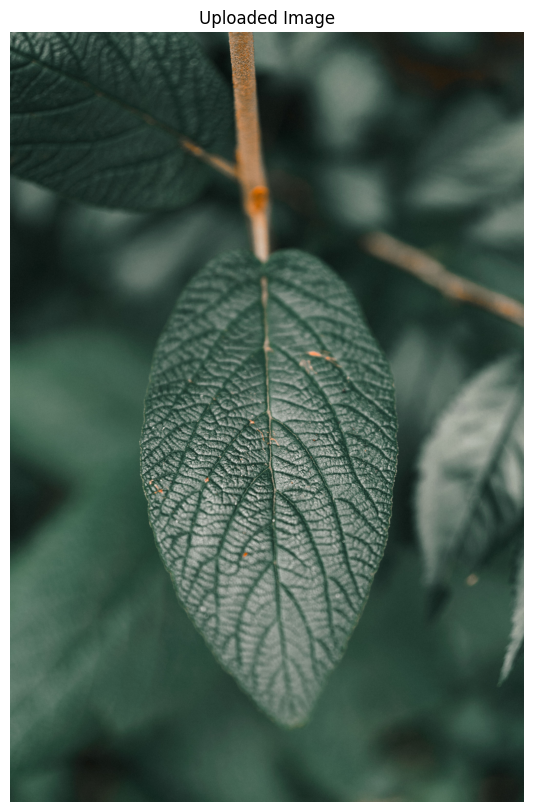

In [292]:
image_name = list(uploaded.keys())[0]
image = cv2.imread(image_name)
image_rgb =cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

In [297]:
test_image = cv2.resize(image, (64,64))
test_image= test_image.reshape(1,-1)
test_image= test_image / 255.0
print("Image Preprocessed Successfully!")

Image Preprocessed Successfully!


In [298]:
prediction = svm_model.predict(test_image)
predicted_disease = encoder.inverse_transform(prediction)
print("Predicted Disease :", predicted_disease[0])

Predicted Disease : Potato___Late_blight


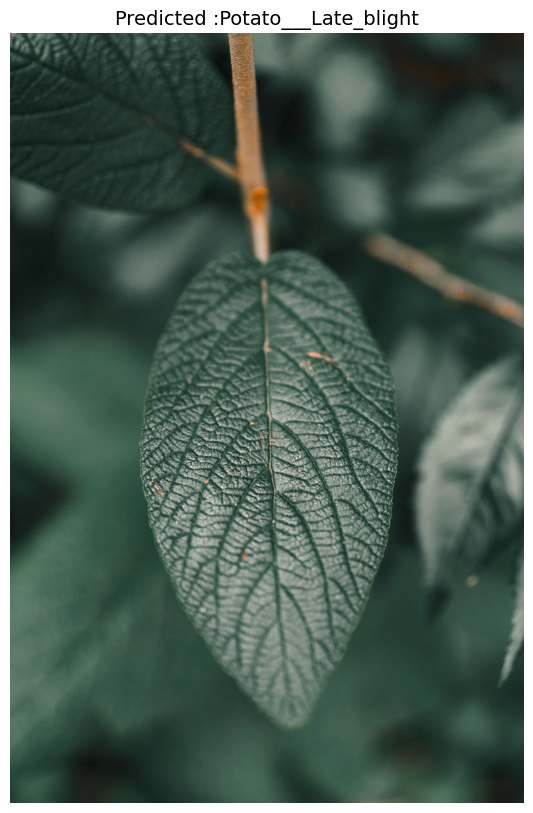

In [299]:
plt.figure(figsize=(10,10))
plt.imshow(image_rgb)
plt.title("Predicted :" + predicted_disease[0], fontsize=14)
plt.axis("off")
plt.show()

In [330]:
if predicted_disease[0] == "potato__Early_blight":
  print("Disease: Early Blight")
  print("Advice: Remove infected leaves and apply a suitable fungicide.")
elif predicted_disease[0] == "potato__Late_blight":
  print("Disease: Late Blight")
  print("Advice: Remove infected leaves and apply a suitable fungicide.")
else:
  print("Disease: Healthy Leaf")
  print("Advice: No disease detected. Continue regular crop care.")

Disease: Healthy Leaf
Advice: No disease detected. Continue regular crop care.


In [334]:
comparison ={
    "Model" : ["Logistic Regression","Support Vector Machine"],
    "Accuracy" : [acc * 100,svm_acc * 100]
}
import pandas as pd
comparison_data = pd.DataFrame(comparison)
comparison_data

,Model,Accuracy
0,Logistic Regression,91.183295
1,Support Vector Machine,91.183295


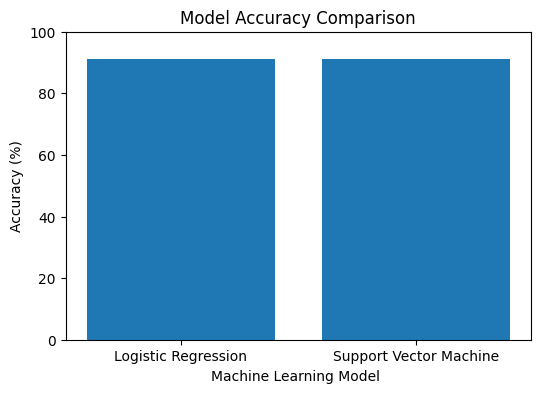

In [337]:
plt.figure(figsize=(6,4))
plt.bar(comparison_data["Model"], comparison_data["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model ")
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)

plt.show()

In [339]:
if svm_acc > acc:
  print("Best Model: Support Vector Machine")
else:
  print("Best Model: Logistic Regression")

Best Model: Logistic Regression
